## Introduction
This notebook trains several machine learning models to predict close price from a property's physical and geographic features and then evaluates their performances.

In [1]:
import numpy as np
import pandas as pd

In [2]:
train = pd.read_csv('clean-data/sold_train.csv')
val = pd.read_csv('clean-data/sold_validation.csv')
test = pd.read_csv('clean-data/sold_test.csv')

## Part 1: Setup
#### 1.1 Load machine learning libraries and preprocessing pipeline

In [3]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from category_encoders import TargetEncoder
from preprocess import GroupwiseImputer, get_preprocessor

In [4]:
# suppress warnings from taking the mean of empty arrays
import warnings
warnings.filterwarnings(action='ignore', message='Mean of empty slice')

# force every transformer to output clean pandas dataframes instead of raw numpy arrays
from sklearn import set_config
set_config(transform_output='pandas')

#### 1.2 Initiate performance tracker
Create a class to compute, log, and manage evaluation metrics across multiple machine learning models.

In [5]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [6]:
class ModelPerformanceTracker:
    # set tracker schema
    def __init__(self):
        self.summary = pd.DataFrame(columns=[
            'Model', 'Feature Size', 'R2', 'RMSE ($)', 'MAE ($)', 'MAPE (%)', 'MdAPE (%)'
        ])

    # calculate evaluation metrics and append them to the summary table
    def log_results(self, model_name, feature_size, y_true, y_pred):
        r2 = r2_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = root_mean_squared_error(y_true, y_pred)

        eps = 1e-8 # have an epsilon in place to prevent division by 0
        percentage_errors = np.abs((y_true - y_pred) / (y_true + eps)) * 100
        mape = np.mean(percentage_errors)
        mdape = np.median(percentage_errors)
        
        model_results = pd.DataFrame([{
            'Model': model_name,
            'Feature Size': feature_size,
            'R2': round(r2, 4),
            'RMSE ($)': round(rmse, 2),
            'MAE ($)': round(mae, 2), 
            'MAPE (%)': round(mape, 2),
            'MdAPE (%)': round(mdape, 2)
        }])
        self.summary = pd.concat([self.summary, model_results], ignore_index=True)

    # return model performance summary sorted by MdAPE  
    def get_summary(self):
        return self.summary.sort_values(by='MdAPE (%)', ascending=True).reset_index(drop=True)

In [7]:
# initiate the validation tracker
val_tracker = ModelPerformanceTracker()

## Part 2: Modeling and Tuning
Train different machine learning models with a predefined feature set.

In [8]:
location_cols = ['MLSAreaMajor', 'CountyOrParish', 'City', 'PostalCode', 'DistrictNa']
bool_cols = ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN'] # removed NewConstructionYN because property age is informative enough
numeric_cols = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'Stories',
                'LotSizeSquareFeet', 'ParkingTotal', 'property_age']
X = location_cols + bool_cols + numeric_cols

In [9]:
X_train = train[X]
y_train = train['ClosePrice']

X_val = val[X]
y_val = val['ClosePrice']

X_test = test[X]
y_test = test['ClosePrice']

#### 2.1 Regression Models
Build linear regression models with a log-transformed target, beginning with ordinary least squares (OLS) and then extending to ridge regression and splines.

In [10]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import SplineTransformer

In [11]:
linear_preprocessor = get_preprocessor(
    location_cols, 
    bool_cols, 
    numeric_cols,
    scale_skewed=True
)

##### OLS

In [12]:
ols_pipeline = Pipeline([
    ('features', linear_preprocessor),
    ('estimator', LinearRegression())
])

ols_model = TransformedTargetRegressor(
    regressor=ols_pipeline, func=np.log1p, inverse_func=np.expm1
)

ols_model.fit(X_train, y_train)
ols_pred_val = ols_model.predict(X_val)
val_tracker.log_results(
    model_name='Linear Regression', 
    feature_size=len(X),
    y_true=y_val, 
    y_pred=ols_pred_val
)

/var/folders/t2/p9112v_n469068__fty8_3nc0000gn/T/ipykernel_57296/3396915426.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.summary = pd.concat([self.summary, model_results], ignore_index=True)


In [13]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Linear Regression,16,0.8046,411566.92,215864.35,16.32,12.28


##### Ridge Regression

In [14]:
ridge_pipeline = Pipeline([
    ('features', linear_preprocessor),
    ('estimator', Ridge(alpha=1.0)) # L2 penalty
])

ridge_model = TransformedTargetRegressor(
    regressor=ridge_pipeline, func=np.log1p, inverse_func=np.expm1
)

ridge_model.fit(X_train, y_train)
ridge_pred_val = ridge_model.predict(X_val)
val_tracker.log_results(
    model_name='Ridge Regression',
    feature_size=len(X),
    y_true=y_val,
    y_pred=ridge_pred_val
)

In [15]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Linear Regression,16,0.8046,411566.92,215864.35,16.32,12.28
1,Ridge Regression,16,0.8046,411568.81,215864.86,16.32,12.28


##### Non-Linear Regression

Given that regularization does not significantly improve the performance of linear regression models, try natural splines to introduce non-linearity.

In [16]:
n_knots = 5
degree = 3 # natural splines use cubic polynomials

In [17]:
spline_transformer = ColumnTransformer(
    transformers=[
        ('splines', 
         SplineTransformer(
             n_knots=n_knots, 
             degree=degree, 
             extrapolation='linear', # enforce linear boundaries
             include_bias=False),    # exclude intercept to reduce multi-collinearity
         make_column_selector(dtype_include=['float64', 'float32', 'int64', 'int32']))
    ],
    remainder='passthrough' 
)

spline_pipeline = Pipeline([
    ('features', linear_preprocessor),
    ('natural_splines', spline_transformer),
    ('estimator', LinearRegression())  
])

spline_model = TransformedTargetRegressor(
    regressor=spline_pipeline, func=np.log1p, inverse_func=np.expm1
)

In [18]:
spline_model.fit(X_train, y_train)
spline_pred_val = spline_model.predict(X_val)
val_tracker.log_results(
    model_name=f'Natural Spline ({n_knots} Knots)',
    feature_size=len(X),
    y_true=y_val,
    y_pred=spline_pred_val
)

In [19]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Natural Spline (5 Knots),16,0.8380,374723.99,201236.53,15.19,11.21
1,Linear Regression,16,0.8046,411566.92,215864.35,16.32,12.28
2,Ridge Regression,16,0.8046,411568.81,215864.86,16.32,12.28


In [20]:
n_knots = 8

In [21]:
spline_transformer = ColumnTransformer(
    transformers=[
        ('splines', 
         SplineTransformer(
             n_knots=n_knots, 
             degree=degree, 
             extrapolation='linear', # enforce linear boundaries
             include_bias=False),    # exclude intercept to reduce multi-collinearity
         make_column_selector(dtype_include=['float64', 'float32', 'int64', 'int32']))
    ],
    remainder='passthrough' 
)

spline_pipeline = Pipeline([
    ('features', linear_preprocessor),
    ('natural_splines', spline_transformer),
    ('estimator', LinearRegression())  
])

spline_model = TransformedTargetRegressor(
    regressor=spline_pipeline, func=np.log1p, inverse_func=np.expm1
)

In [22]:
spline_model.fit(X_train, y_train)
spline_pred_val = spline_model.predict(X_val)
val_tracker.log_results(
    model_name=f'Natural Spline ({n_knots} Knots)',
    feature_size=len(X),
    y_true=y_val,
    y_pred=spline_pred_val
)

In [23]:
# increasing the number of knots provides only marginal improvement in MdAPE, suggesting more advanced models are needed
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Natural Spline (8 Knots),16,0.8391,373470.64,200254.63,15.06,11.09
1,Natural Spline (5 Knots),16,0.8380,374723.99,201236.53,15.19,11.21
2,Linear Regression,16,0.8046,411566.92,215864.35,16.32,12.28
3,Ridge Regression,16,0.8046,411568.81,215864.86,16.32,12.28


#### 2.2 Tree-Based Models
Build tree-based models with a log-transformed target, beginning with decision tree and then extending to random forest and gradient boosting.

In [24]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [25]:
tree_preprocessor = get_preprocessor(
    location_cols, 
    bool_cols, 
    numeric_cols,
    scale_skewed=False # no need to normalize numeric features for tree architectures
)

##### Decision Trees

In [26]:
depth = 12

In [27]:
dt_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', DecisionTreeRegressor(max_depth=depth, random_state=42))
])

dt_model = TransformedTargetRegressor(
    regressor=dt_pipeline, func=np.log1p, inverse_func=np.expm1
)

dt_model.fit(X_train, y_train)
dt_pred_val = dt_model.predict(X_val)
val_tracker.log_results(
    model_name=f'Decision Tree (Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=dt_pred_val
)

In [28]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Decision Tree (Depth=12),16,0.8388,373769.92,194547.93,14.46,10.23
1,Natural Spline (8 Knots),16,0.8391,373470.64,200254.63,15.06,11.09
2,Natural Spline (5 Knots),16,0.8380,374723.99,201236.53,15.19,11.21
3,Linear Regression,16,0.8046,411566.92,215864.35,16.32,12.28
4,Ridge Regression,16,0.8046,411568.81,215864.86,16.32,12.28


In [29]:
depth = 10

In [30]:
dt_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', DecisionTreeRegressor(max_depth=depth, random_state=42))
])

dt_model = TransformedTargetRegressor(
    regressor=dt_pipeline, func=np.log1p, inverse_func=np.expm1
)

dt_model.fit(X_train, y_train)
dt_pred_val = dt_model.predict(X_val)
val_tracker.log_results(
    model_name=f'Decision Tree (Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=dt_pred_val
)

In [31]:
# a shallower tree shows decline in performance, suggesting underfitting
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Decision Tree (Depth=12),16,0.8388,373769.92,194547.93,14.46,10.23
1,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
2,Natural Spline (8 Knots),16,0.8391,373470.64,200254.63,15.06,11.09
3,Natural Spline (5 Knots),16,0.8380,374723.99,201236.53,15.19,11.21
4,Linear Regression,16,0.8046,411566.92,215864.35,16.32,12.28
5,Ridge Regression,16,0.8046,411568.81,215864.86,16.32,12.28


In [32]:
depth = 14

In [33]:
dt_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', DecisionTreeRegressor(max_depth=depth, random_state=42))
])

dt_model = TransformedTargetRegressor(
    regressor=dt_pipeline, func=np.log1p, inverse_func=np.expm1
)

dt_model.fit(X_train, y_train)
dt_pred_val = dt_model.predict(X_val)
val_tracker.log_results(
    model_name=f'Decision Tree (Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=dt_pred_val
)

In [34]:
# a slight increase in tree depth notably improves performance; try increasing it further
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Decision Tree (Depth=14),16,0.8362,376809.64,192123.21,14.17,9.68
1,Decision Tree (Depth=12),16,0.8388,373769.92,194547.93,14.46,10.23
2,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
3,Natural Spline (8 Knots),16,0.8391,373470.64,200254.63,15.06,11.09
4,Natural Spline (5 Knots),16,0.8380,374723.99,201236.53,15.19,11.21
5,Linear Regression,16,0.8046,411566.92,215864.35,16.32,12.28
6,Ridge Regression,16,0.8046,411568.81,215864.86,16.32,12.28


In [35]:
depth = 16

In [36]:
dt_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', DecisionTreeRegressor(max_depth=depth, random_state=42))
])

dt_model = TransformedTargetRegressor(
    regressor=dt_pipeline, func=np.log1p, inverse_func=np.expm1
)

dt_model.fit(X_train, y_train)
dt_pred_val = dt_model.predict(X_val)
val_tracker.log_results(
    model_name=f'Decision Tree (Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=dt_pred_val
)

In [37]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Decision Tree (Depth=16),16,0.8231,391547.83,196581.10,14.42,9.53
1,Decision Tree (Depth=14),16,0.8362,376809.64,192123.21,14.17,9.68
2,Decision Tree (Depth=12),16,0.8388,373769.92,194547.93,14.46,10.23
3,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
4,Natural Spline (8 Knots),16,0.8391,373470.64,200254.63,15.06,11.09
5,Natural Spline (5 Knots),16,0.8380,374723.99,201236.53,15.19,11.21
6,Linear Regression,16,0.8046,411566.92,215864.35,16.32,12.28
7,Ridge Regression,16,0.8046,411568.81,215864.86,16.32,12.28


In [38]:
depth = 18

In [39]:
dt_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', DecisionTreeRegressor(max_depth=depth, random_state=42))
])

dt_model = TransformedTargetRegressor(
    regressor=dt_pipeline, func=np.log1p, inverse_func=np.expm1
)

dt_model.fit(X_train, y_train)
dt_pred_val = dt_model.predict(X_val)
val_tracker.log_results(
    model_name=f'Decision Tree (Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=dt_pred_val
)

In [40]:
# MdAPE worsened with increased tree depth, suggesting limited benefit from deeper trees
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,Decision Tree (Depth=16),16,0.8231,391547.83,196581.10,14.42,9.53
1,Decision Tree (Depth=18),16,0.8113,404440.88,201064.76,14.76,9.59
2,Decision Tree (Depth=14),16,0.8362,376809.64,192123.21,14.17,9.68
3,Decision Tree (Depth=12),16,0.8388,373769.92,194547.93,14.46,10.23
4,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
5,Natural Spline (8 Knots),16,0.8391,373470.64,200254.63,15.06,11.09
6,Natural Spline (5 Knots),16,0.8380,374723.99,201236.53,15.19,11.21
7,Linear Regression,16,0.8046,411566.92,215864.35,16.32,12.28
8,Ridge Regression,16,0.8046,411568.81,215864.86,16.32,12.28


##### Random Forests

In [41]:
n_trees = 150
depth = 16 # based on the decision tree evaluations earlier

In [42]:
rf_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', RandomForestRegressor(n_estimators=n_trees, max_depth=depth, random_state=42, n_jobs=-1))
])

rf_model = TransformedTargetRegressor(
    regressor=rf_pipeline, func=np.log1p, inverse_func=np.expm1
)

rf_model.fit(X_train, y_train)
rf_pred_val = rf_model.predict(X_val)
val_tracker.log_results(
    model_name=f'Random Forest ({n_trees} Trees, Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=rf_pred_val
)

In [43]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,"Random Forest (150 Trees, Depth=16)",16,0.8848,315976.67,162400.94,11.90,8.29
1,Decision Tree (Depth=16),16,0.8231,391547.83,196581.10,14.42,9.53
2,Decision Tree (Depth=18),16,0.8113,404440.88,201064.76,14.76,9.59
3,Decision Tree (Depth=14),16,0.8362,376809.64,192123.21,14.17,9.68
4,Decision Tree (Depth=12),16,0.8388,373769.92,194547.93,14.46,10.23
5,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
6,Natural Spline (8 Knots),16,0.8391,373470.64,200254.63,15.06,11.09
7,Natural Spline (5 Knots),16,0.8380,374723.99,201236.53,15.19,11.21
8,Linear Regression,16,0.8046,411566.92,215864.35,16.32,12.28
9,Ridge Regression,16,0.8046,411568.81,215864.86,16.32,12.28


In [44]:
n_trees = 180

In [45]:
rf_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', RandomForestRegressor(n_estimators=n_trees, max_depth=depth, random_state=42, n_jobs=-1))
])

rf_model = TransformedTargetRegressor(
    regressor=rf_pipeline, func=np.log1p, inverse_func=np.expm1
)

rf_model.fit(X_train, y_train)
rf_pred_val = rf_model.predict(X_val)
val_tracker.log_results(
    model_name=f'Random Forest ({n_trees} Trees, Depth={depth})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=rf_pred_val
)

In [46]:
# increasing the number of trees yields worse MdAPE, suggesting more advanced models are needed
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,"Random Forest (150 Trees, Depth=16)",16,0.8848,315976.67,162400.94,11.90,8.29
1,"Random Forest (180 Trees, Depth=16)",16,0.8852,315426.93,162322.36,11.90,8.31
2,Decision Tree (Depth=16),16,0.8231,391547.83,196581.10,14.42,9.53
3,Decision Tree (Depth=18),16,0.8113,404440.88,201064.76,14.76,9.59
4,Decision Tree (Depth=14),16,0.8362,376809.64,192123.21,14.17,9.68
5,Decision Tree (Depth=12),16,0.8388,373769.92,194547.93,14.46,10.23
6,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
7,Natural Spline (8 Knots),16,0.8391,373470.64,200254.63,15.06,11.09
8,Natural Spline (5 Knots),16,0.8380,374723.99,201236.53,15.19,11.21
9,Linear Regression,16,0.8046,411566.92,215864.35,16.32,12.28


##### Gradient Boosting

Both random forest and gradient boosting are ensembles of decision trees. However, gradient boosting builds trees sequentially, with each new tree focusing on the errors made by the previous one, which allows it to capture complex patterns more effectively in many cases, so explore gradient boosting models next.

Start with XGBoost, which controls tree complexity primarily through the depth of each tree, and then explore LightGBM, which controls complexity through the number of leaves.

In [47]:
import xgboost as xgb
import lightgbm as lgb

In [48]:
n_trees = 800 # lowering the number of trees gradually improved accuracy
depth = 14 # lower than the optimal depth determined from decision tree evaluations
learning_rate = 0.04 # keep the rate relatively small to learn the complexities

In [49]:
xgb_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', xgb.XGBRegressor(n_estimators=n_trees, 
                                   learning_rate=learning_rate,     
                                   max_depth=depth,     
                                   random_state=42))
])

xgb_model = TransformedTargetRegressor(
    regressor=xgb_pipeline, func=np.log1p, inverse_func=np.expm1
)

In [50]:
xgb_model.fit(X_train, y_train)
xgb_pred_val = xgb_model.predict(X_val)
val_tracker.log_results(
    model_name=f'XGBoost ({n_trees} Trees, Depth={depth}, Learning Rate={learning_rate})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=xgb_pred_val
)

In [51]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,"XGBoost (800 Trees, Depth=14, Learning Rate=0.04)",16,0.8885,310827.17,154938.38,11.33,7.60
1,"Random Forest (150 Trees, Depth=16)",16,0.8848,315976.67,162400.94,11.90,8.29
2,"Random Forest (180 Trees, Depth=16)",16,0.8852,315426.93,162322.36,11.90,8.31
3,Decision Tree (Depth=16),16,0.8231,391547.83,196581.10,14.42,9.53
4,Decision Tree (Depth=18),16,0.8113,404440.88,201064.76,14.76,9.59
5,Decision Tree (Depth=14),16,0.8362,376809.64,192123.21,14.17,9.68
6,Decision Tree (Depth=12),16,0.8388,373769.92,194547.93,14.46,10.23
7,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
8,Natural Spline (8 Knots),16,0.8391,373470.64,200254.63,15.06,11.09
9,Natural Spline (5 Knots),16,0.8380,374723.99,201236.53,15.19,11.21


In [52]:
n_leaves = 40 # branching out more improved validation accuracy, but anything past 40 yielded marginal improvement
n_trees = 2000 # increasing the number of trees improved validation accuracy

In [53]:
lgb_pipeline = Pipeline([
    ('features', tree_preprocessor),
    ('estimator', lgb.LGBMRegressor(n_estimators=n_trees, 
                                    learning_rate=learning_rate,     
                                    max_depth=depth, 
                                    num_leaves=n_leaves,     
                                    random_state=42))
])

lgb_model = TransformedTargetRegressor(
    regressor=lgb_pipeline, func=np.log1p, inverse_func=np.expm1
)

In [54]:
lgb_model.fit(X_train, y_train)
lgb_pred_val = lgb_model.predict(X_val)
val_tracker.log_results(
    model_name=f'LightGBM ({n_trees} Trees, {n_leaves} Leaves, Depth={depth}, Learning Rate={learning_rate})',
    feature_size=len(X),
    y_true=y_val,
    y_pred=lgb_pred_val
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005333 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1769
[LightGBM] [Info] Number of data points in the train set: 164431, number of used features: 16
[LightGBM] [Info] Start training from score 13.765797


In [55]:
val_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,"XGBoost (800 Trees, Depth=14, Learning Rate=0.04)",16,0.8885,310827.17,154938.38,11.33,7.60
1,"LightGBM (2000 Trees, 40 Leaves, Depth=14, Lea...",16,0.9004,293823.84,151172.04,11.11,7.80
2,"Random Forest (150 Trees, Depth=16)",16,0.8848,315976.67,162400.94,11.90,8.29
3,"Random Forest (180 Trees, Depth=16)",16,0.8852,315426.93,162322.36,11.90,8.31
4,Decision Tree (Depth=16),16,0.8231,391547.83,196581.10,14.42,9.53
5,Decision Tree (Depth=18),16,0.8113,404440.88,201064.76,14.76,9.59
6,Decision Tree (Depth=14),16,0.8362,376809.64,192123.21,14.17,9.68
7,Decision Tree (Depth=12),16,0.8388,373769.92,194547.93,14.46,10.23
8,Decision Tree (Depth=10),16,0.8461,365199.90,196417.57,14.67,10.67
9,Natural Spline (8 Knots),16,0.8391,373470.64,200254.63,15.06,11.09


## Part 3: Evaluation
The LightGBM model explained the most variation in close price (R² = 0.9004), while XGBoost achieved the lowest MdAPE (7.6%) on the validation data. Both models demonstrated strong predictive performance, so proceed to evaluate their accuracy and stability on the test data.

#### 3.1 Overall Accuracy

In [56]:
# initiate the test tracker
test_tracker = ModelPerformanceTracker()

In [57]:
xgb_pred_test = xgb_model.predict(X_test)
test_tracker.log_results(
    model_name=f'XGBoost ({n_trees} Trees, Depth={depth}, Learning Rate={learning_rate})',
    feature_size=len(X),
    y_true=y_test,
    y_pred=xgb_pred_test
)

lgb_pred_test = lgb_model.predict(X_test)
test_tracker.log_results(
    model_name=f'LightGBM ({n_trees} Trees, {n_leaves} Leaves, Depth={depth}, Learning Rate={learning_rate})',
    feature_size=len(X),
    y_true=y_test,
    y_pred=lgb_pred_test
)

/var/folders/t2/p9112v_n469068__fty8_3nc0000gn/T/ipykernel_57296/3396915426.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.summary = pd.concat([self.summary, model_results], ignore_index=True)


In [58]:
test_tracker.get_summary()

,Model,Feature Size,R2,RMSE ($),MAE ($),MAPE (%),MdAPE (%)
0,"XGBoost (2000 Trees, Depth=14, Learning Rate=0...",16,0.8965,300825.21,153303.72,11.32,7.62
1,"LightGBM (2000 Trees, 40 Leaves, Depth=14, Lea...",16,0.9033,290822.41,149700.02,11.07,7.87


#### 3.2 Accuracy by Price Tiers

Both models seem to predict lower priced properties (<$3 million) more accurately than more luxury properties, suggesting that performance declines as price increases.

In [59]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Predicted Price')

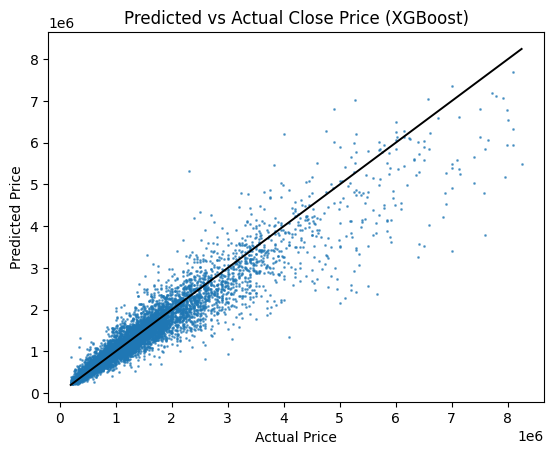

In [60]:
plt.scatter(y_test, xgb_pred_test, alpha=0.6, s=1)

limits = [min(min(y_test), min(xgb_pred_test)), max(max(y_test), max(xgb_pred_test))]
plt.plot(limits, limits, color='black', linestyle='-', linewidth=1.4)

plt.title('Predicted vs Actual Close Price (XGBoost)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

Text(0, 0.5, 'Predicted Price')

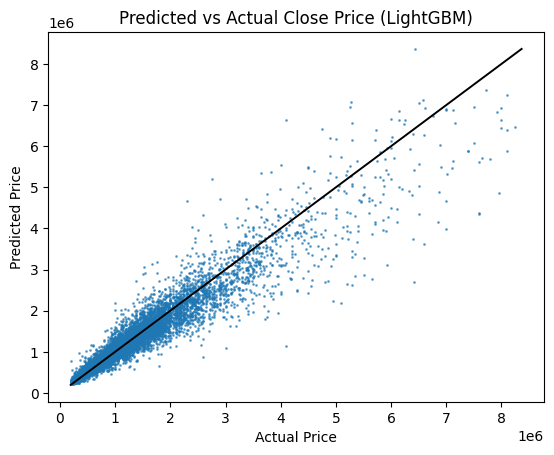

In [61]:
plt.scatter(y_test, lgb_pred_test, alpha=0.6, s=1)

limits = [min(min(y_test), min(lgb_pred_test)), max(max(y_test), max(lgb_pred_test))]
plt.plot(limits, limits, color='black', linestyle='-', linewidth=1.4)

plt.title('Predicted vs Actual Close Price (LightGBM)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

Divide the test data into close-price quartiles and compare predictive accuracy across quartiles.

In [62]:
# helper function that calculates performance metrics by close-price quartile for each model
def evaluate_by_quartile(y_true, y_pred):
    results = pd.DataFrame({
        'Actual Price': y_true,
        'Predicted Price': y_pred
    })

    results['Price Quartile'] = pd.qcut(
        results['Actual Price'], 
        q=4, 
        labels=['Q1', 'Q2', 'Q3', 'Q4']
    )
    eps = 1e-8 # used to prevent division by 0 in percentage calculations

    # prioritize percentage-based metrics such as MdAPE and MAPE, as MAE and RMSE naturally increase with price
    metrics = results.groupby('Price Quartile', observed=True).apply(
        lambda x: pd.Series({
            'MdAPE': np.median(np.abs((x['Actual Price'] - x['Predicted Price']) / (x['Actual Price'] + eps)) * 100),
            'MAPE': np.mean(np.abs((x['Actual Price'] - x['Predicted Price']) / (x['Actual Price'] + eps)) * 100),
            'MAE': mean_absolute_error(x['Actual Price'], x['Predicted Price']),
            'RMSE': root_mean_squared_error(x['Actual Price'], x['Predicted Price']),
            'R²': r2_score(x['Actual Price'], x['Predicted Price'])
        })
    )
    return metrics

In [63]:
# XGBoost yielded the lowest MdAPE in Q2
# NOTE: Q2 and Q3 returned negative R2, suggesting worse performance than a base model predicting overall mean
xgb_quartile_performance = evaluate_by_quartile(y_test, xgb_pred_test)
print(xgb_quartile_performance)

                    MdAPE       MAPE            MAE           RMSE        R²
Price Quartile                                                              
Q1               6.590214  11.382420   50980.956118   84092.803865  0.339906
Q2               5.865914   8.567677   66736.325174   97222.027486 -0.446644
Q3               8.136506  11.254514  130638.853397  183913.016402 -0.408138
Q4              10.965176  14.099511  365733.103715  558746.158827  0.748205


/var/folders/t2/p9112v_n469068__fty8_3nc0000gn/T/ipykernel_57296/112362347.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics = results.groupby('Price Quartile', observed=True).apply(


In [64]:
# LightGBM also yielded the lowest MdAPE in Q2 (though not substantially lower than the MdAPE in Q1)
# NOTE: Q2 and Q3 returned negative R2, suggesting worse performance than a base model predicting overall mean
lgb_quartile_performance = evaluate_by_quartile(y_test, lgb_pred_test)
print(lgb_quartile_performance)

                    MdAPE       MAPE            MAE           RMSE        R²
Price Quartile                                                              
Q1               6.749669  11.032384   49460.458831   76790.068628  0.449575
Q2               6.273188   8.563046   66637.397782   93400.509469 -0.335152
Q3               8.307901  11.086354  128964.977699  179055.692437 -0.334740
Q4              10.668522  13.634948  354585.725831  540517.844169  0.764366


/var/folders/t2/p9112v_n469068__fty8_3nc0000gn/T/ipykernel_57296/112362347.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics = results.groupby('Price Quartile', observed=True).apply(


#### 3.3 Rolling-Origin Backtest

Evaluate model stability using a rolling-origin backtest that starts with the earliest month of data available (January 2024), using 16 months of data for training as defined during the training process and the following month for testing. Roll the training and testing windows forward by one month at a time until reaching the most recent month of data available (June 2026).

##### Setup
Create reusable functions to apply consistent outlier thresholds across training and test data in each iteration.

In [65]:
# helper function that calculates outlier thresholds from training data
def get_outlier_thresholds(X, y, lower=0.005, upper=0.995):
    price_per_sqft = y / X['LivingArea']
    thresholds = {
        'price_lower': y.quantile(lower),
        'price_upper': y.quantile(upper),
        'price_per_sqft_lower': price_per_sqft.quantile(lower),
        'price_per_sqft_upper': price_per_sqft.quantile(upper)
    }
    return thresholds

# helper function that applies the thresholds to a given data
def apply_outlier_thresholds(X, y, thresholds):
    price_per_sqft = y / X['LivingArea']
    within_bounds = (
        y.between(
            thresholds['price_lower'], 
            thresholds['price_upper']
        ) & 
        price_per_sqft.between(
            thresholds['price_per_sqft_lower'], 
            thresholds['price_per_sqft_upper']
        )
    )
    return X.loc[within_bounds], y.loc[within_bounds]


Load the full data set and derive year and month from close date for looping

In [66]:
sold = pd.read_csv('clean-data/sold_clean_transformed.csv')

In [67]:
sold['year_month'] = pd.to_datetime(sold['CloseDate']).dt.to_period('M')
months = pd.period_range(
    start=sold['year_month'].min(),
    end=sold['year_month'].max(),
    freq='M'
)

##### Rolling-Origin Loop

In [68]:
training_window = 16 # hyperparameter tuned during model development
eps = 1e-8

Run the loop separately for the two models, starting with LightGBM.

In [69]:
# parameters tuned during model development
n_trees = 2000
learning_rate = 0.04
depth = 14
n_leaves = 40

# initiate the performance tracker for LightGBM
lgb_results = []

In [70]:
for i in range(training_window, len(months)):
    # -------------------------------------------
    # (i) define training and test periods
    # -------------------------------------------
    train_start_month = months[i - 16]
    train_end_month = months[i - 1]
    test_month = months[i]

    sold_train = sold[sold['year_month'].between(train_start_month, train_end_month)].copy()
    sold_test = sold[sold['year_month'] == test_month].copy()

    # -------------------------------------------
    # (ii) separate features and target
    # -------------------------------------------
    X_train = sold_train[X]
    y_train = sold_train['ClosePrice']
    X_test = sold_test[X]
    y_test = sold_test['ClosePrice']

    # -------------------------------------------
    # (iii) preprocess training and test sets
    # -------------------------------------------
    # filter out price outliers using training-learned thresholds
    thresholds = get_outlier_thresholds(X_train, y_train)
    X_train, y_train = apply_outlier_thresholds(X_train, y_train, thresholds)
    X_test, y_test = apply_outlier_thresholds(X_test, y_test, thresholds)

    # set up the rest of the preprocessing pipeline
    preprocessor = get_preprocessor(
        location_cols,
        bool_cols,
        numeric_cols,
        scale_skewed=False # no need to normalize for LightGBM
    )

    lgb_pipeline = Pipeline([
        ('features', preprocessor),
        ('estimator', lgb.LGBMRegressor(
            n_estimators=n_trees, 
            learning_rate=learning_rate,     
            max_depth=depth, 
            num_leaves=n_leaves,     
            random_state=42
        ))
    ])

    lgb_model = TransformedTargetRegressor(
        regressor=lgb_pipeline, 
        func=np.log1p, 
        inverse_func=np.expm1
    )

    # -------------------------------------------
    # (iv) fit the model and calculate metrics
    # -------------------------------------------
    lgb_model.fit(X_train, y_train)
    lgb_pred = lgb_model.predict(X_test)
    lgb_results.append({
            'train_start_month': train_start_month,
            'train_end_month': train_end_month,
            'test_month': test_month,
            'MdAPE': np.median(np.abs((y_test - lgb_pred) / (y_test + eps)) * 100),
            'MAPE': np.mean(np.abs((y_test - lgb_pred) / (y_test + eps)) * 100),
            'MAE': mean_absolute_error(y_test, lgb_pred),
            'RMSE': root_mean_squared_error(y_test, lgb_pred),
            'R²': r2_score(y_test, lgb_pred)
    })

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004495 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1768
[LightGBM] [Info] Number of data points in the train set: 172600, number of used features: 16
[LightGBM] [Info] Start training from score 13.774340
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1773
[LightGBM] [Info] Number of data points in the train set: 175899, number of used features: 16
[LightGBM] [Info] Start training from score 13.780765
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005820 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

In [71]:
lgb_results = pd.DataFrame(lgb_results)
lgb_results

,train_start_month,train_end_month,test_month,MdAPE,MAPE,MAE,RMSE,R²
0,2024-01,2025-04,2025-05,7.674287,10.919119,146098.288468,286722.936512,0.897116
1,2024-02,2025-05,2025-06,7.657354,10.801152,145072.194840,286802.788101,0.903753
2,2024-03,2025-06,2025-07,7.675285,11.029129,140369.143522,268258.216197,0.909618
3,2024-04,2025-07,2025-08,7.603880,11.285264,140568.433773,277639.886698,0.897986
4,2024-05,2025-08,2025-09,7.682064,11.294946,138458.355907,265926.890123,0.903688
5,2024-06,2025-09,2025-10,7.844483,11.280319,142395.552169,275147.726809,0.904367
6,2024-07,2025-10,2025-11,7.817596,11.300641,141709.221215,271039.372210,0.907906
7,2024-08,2025-11,2025-12,7.802760,11.415459,137153.371621,269476.011297,0.903421
8,2024-09,2025-12,2026-01,7.743926,11.750733,144944.260064,292407.728963,0.893551
9,2024-10,2026-01,2026-02,7.865488,11.458317,150375.411163,308599.853543,0.892588


In [72]:
# MdAPE and R2 show relatively small variation across iterations
metrics = ['MdAPE', 'MAPE', 'MAE', 'RMSE', 'R²']
lgb_results[metrics].describe()

,MdAPE,MAPE,MAE,RMSE,R²
count,14.000000,14.000000,14.000000,14.000000,14.000000
mean,7.775552,11.231424,145159.371625,285283.101084,0.900810
std,0.104215,0.242077,5483.538132,14840.191310,0.005516
min,7.603880,10.801152,137153.371621,265926.890123,0.892588
25%,7.676979,11.057909,140853.630633,272066.460860,0.896336
50%,7.810178,11.282792,145008.227452,286253.814722,0.903207
75%,7.844421,11.344781,149171.075915,292395.079014,0.904213
max,7.975163,11.750733,154489.410895,308599.853543,0.909618


Then onto XGBoost.

In [73]:
# parameters tuned during model development
n_trees = 800
learning_rate = 0.04
depth = 14

# initiate the performance tracker for XGBoost
xgb_results = []

In [74]:
for i in range(training_window, len(months)):
    # -------------------------------------------
    # (i) define training and test periods
    # -------------------------------------------
    train_start_month = months[i - 16]
    train_end_month = months[i - 1]
    test_month = months[i]

    sold_train = sold[sold['year_month'].between(train_start_month, train_end_month)].copy()
    sold_test = sold[sold['year_month'] == test_month].copy()

    # -------------------------------------------
    # (ii) separate features and target
    # -------------------------------------------
    X_train = sold_train[X]
    y_train = sold_train['ClosePrice']
    X_test = sold_test[X]
    y_test = sold_test['ClosePrice']

    # -------------------------------------------
    # (iii) preprocess training and test sets
    # -------------------------------------------
    # filter out price outliers using training-learned thresholds
    thresholds = get_outlier_thresholds(X_train, y_train)
    X_train, y_train = apply_outlier_thresholds(X_train, y_train, thresholds)
    X_test, y_test = apply_outlier_thresholds(X_test, y_test, thresholds)

    # set up the rest of the preprocessing pipeline
    preprocessor = get_preprocessor(
        location_cols,
        bool_cols,
        numeric_cols,
        scale_skewed=False # no need to normalize for XGBoost
    )

    xgb_pipeline = Pipeline([
        ('features', preprocessor),
        ('estimator', xgb.XGBRegressor(
            n_estimators=n_trees, 
            learning_rate=learning_rate,     
            max_depth=depth,    
            random_state=42
        ))
    ])

    xgb_model = TransformedTargetRegressor(
        regressor=xgb_pipeline, 
        func=np.log1p, 
        inverse_func=np.expm1
    )

    # -------------------------------------------
    # (iv) fit the model and calculate metrics
    # -------------------------------------------
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    xgb_results.append({
            'train_start_month': train_start_month,
            'train_end_month': train_end_month,
            'test_month': test_month,
            'MdAPE': np.median(np.abs((y_test - xgb_pred) / (y_test + eps)) * 100),
            'MAPE': np.mean(np.abs((y_test - xgb_pred) / (y_test + eps)) * 100),
            'MAE': mean_absolute_error(y_test, xgb_pred),
            'RMSE': root_mean_squared_error(y_test, xgb_pred),
            'R²': r2_score(y_test, xgb_pred)
    })

In [75]:
xgb_results = pd.DataFrame(xgb_results)
xgb_results

,train_start_month,train_end_month,test_month,MdAPE,MAPE,MAE,RMSE,R²
0,2024-01,2025-04,2025-05,7.585048,11.089082,147866.700146,296321.940046,0.890112
1,2024-02,2025-05,2025-06,7.445008,10.983696,147782.714154,296086.037950,0.897422
2,2024-03,2025-06,2025-07,7.466281,11.137688,142579.065864,275678.047568,0.904549
3,2024-04,2025-07,2025-08,7.549728,11.410660,142952.669582,287948.697291,0.890270
4,2024-05,2025-08,2025-09,7.644220,11.451073,142104.282791,279880.673871,0.893315
5,2024-06,2025-09,2025-10,7.671583,11.450516,146221.397987,294448.657621,0.890480
6,2024-07,2025-10,2025-11,7.593015,11.371718,143276.739541,280878.609018,0.901098
7,2024-08,2025-11,2025-12,7.697062,11.575198,140889.740258,284405.364029,0.892423
8,2024-09,2025-12,2026-01,7.799408,11.891156,148155.742419,303955.275145,0.884977
9,2024-10,2026-01,2026-02,7.974841,11.759387,154662.282139,320974.482476,0.883801


In [76]:
# XGBoost shows larger variation in MdAPE and R2 across iterations but lower mean MdAPE compared to LightGBM
xgb_results[metrics].describe()

,MdAPE,MAPE,MAE,RMSE,R²
count,14.000000,14.000000,14.000000,14.000000,14.000000
mean,7.673195,11.411506,148289.543195,297190.688945,0.892322
std,0.148352,0.254488,5820.901168,15176.328110,0.006387
min,7.445008,10.983696,140889.740258,275678.047568,0.883801
25%,7.587040,11.246899,143033.687072,285291.197344,0.887947
50%,7.657902,11.421883,147824.707150,296203.988998,0.891451
75%,7.779050,11.544167,152306.273979,303415.552690,0.896761
max,7.974841,11.891156,158413.123671,321661.749810,0.904549


## Conclusion
Several rounds of machine learning models were developed to predict close price, beginning with linear regression and progressing to tree-based models. LightGBM and XGBoost were ultimately selected based on their low MdAPE and high R² on the validation set.

Both models were then evaluated on the test set and in a rolling-origin backtest using the same parameter settings selected during model development to assess predictive accuracy and stability. Both showed greater predictive accuracy for lower-priced properties (Q2) in the test set. LightGBM demonstrated more stable MdAPE and (R^2) across backtest periods, while XGBoost achieved comparatively lower mean MdAPE.
